# NB06: Fitness Browser Cross-Reference

**Goal**: Test H6 — do AMR genes impose measurable fitness costs? For the ~48 Fitness Browser organisms, identify which carry AMR genes in the pangenome, then extract fitness effects.

**Caveats**:
- Only 48 FB organisms, not all will have AMR genes in bakta_amr
- FB fitness values are STRING type — must CAST before numeric operations
- This is exploratory — small sample size limits statistical power

**Depends on**: NB01 outputs + Spark session

**Outputs**:
- `../data/amr_fitness.csv`
- `../figures/amr_fitness_*.png`

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

try:
    spark = get_spark_session()
except NameError:
    sys.path.insert(0, os.path.join(os.getcwd(), '..', '..', '..', 'scripts'))
    from get_spark_session import get_spark_session
    spark = get_spark_session()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 150, 'font.size': 11,
    'axes.titlesize': 13, 'savefig.bbox': 'tight', 'savefig.dpi': 150,
})

amr = pd.read_csv(DATA_DIR / 'amr_census.csv')
print(f"Loaded {len(amr):,} AMR clusters")

Loaded 83,008 AMR clusters


## 1. Load FB-Pangenome Link Table

The `conservation_vs_fitness` project built a sequence-level link table via DIAMOND:
FB protein sequences → pangenome cluster representatives at 100% identity.
This gives us direct `locusId → gene_cluster_id` mappings (177K links).

In [2]:
# Load the FB-pangenome link table from lakehouse (built by conservation_vs_fitness via DIAMOND)
fb_links = spark.read.csv(
    's3a://cdm-lake/tenant-general-warehouse/microbialdiscoveryforge/projects/conservation_vs_fitness/data/fb_pangenome_link.tsv',
    header=True, sep='\t'
).toPandas()

print(f"FB-pangenome link table: {len(fb_links):,} links")
print(f"Organisms: {fb_links['orgId'].nunique()}")
print(f"Gene clusters: {fb_links['gene_cluster_id'].nunique():,}")

# Find AMR genes in FB via sequence-level links
fb_amr = fb_links.merge(
    amr[['gene_cluster_id', 'amr_gene', 'amr_product', 'conservation_class', 'mechanism']].drop_duplicates('gene_cluster_id'),
    on='gene_cluster_id', how='inner'
)

print(f"\nFB genes with AMR annotations (via sequence match): {len(fb_amr):,}")
print(f"Distinct FB organisms with AMR genes: {fb_amr['orgId'].nunique()}")
print(f"Distinct AMR gene families: {fb_amr['amr_gene'].nunique()}")

print(f"\n=== AMR Genes per FB Organism ===")
org_counts = fb_amr.groupby('orgId').size().sort_values(ascending=False)
for org, n in org_counts.items():
    print(f"  {org}: {n} AMR genes")

FB-pangenome link table: 177,863 links
Organisms: 44
Gene clusters: 163,974

FB genes with AMR annotations (via sequence match): 178
Distinct FB organisms with AMR genes: 37
Distinct AMR gene families: 71

=== AMR Genes per FB Organism ===
  ANA3: 22 AMR genes
  PS: 15 AMR genes
  Putida: 12 AMR genes
  SyringaeB728a: 10 AMR genes
  Koxy: 10 AMR genes
  Korea: 8 AMR genes
  DdiaME23: 8 AMR genes
  pseudo1_N1B4: 7 AMR genes
  acidovorax_3H11: 6 AMR genes
  Smeli: 6 AMR genes
  pseudo6_N2E2: 6 AMR genes
  pseudo13_GW456_L13: 5 AMR genes
  pseudo3_N2E3: 5 AMR genes
  pseudo5_N2C3_1: 4 AMR genes
  Cup4G11: 4 AMR genes
  Btheta: 4 AMR genes
  BFirm: 4 AMR genes
  Ddia6719: 4 AMR genes
  MR1: 4 AMR genes
  WCS417: 3 AMR genes
  HerbieS: 3 AMR genes
  Marino: 3 AMR genes
  Dda3937: 3 AMR genes
  PV4: 3 AMR genes
  Caulo: 2 AMR genes
  Dyella79: 2 AMR genes
  SyringaeB728a_mexBdelta: 2 AMR genes
  psRCH2: 2 AMR genes
  Ponti: 2 AMR genes
  azobra: 2 AMR genes
  RalstoniaBSBF1503: 1 AMR genes
 

In [3]:
# Get fitness data for all FB-AMR genes
amr_loci = fb_amr['locusId'].unique().tolist()
print(f"Querying fitness for {len(amr_loci):,} AMR loci...")

def chunked_query(spark, ids, query_template, chunk_size=500):
    results = []
    for i in range(0, len(ids), chunk_size):
        chunk = ids[i:i+chunk_size]
        id_list = "','".join(str(x) for x in chunk)
        query = query_template.format(id_list=f"'{id_list}'")
        results.append(spark.sql(query).toPandas())
    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()

amr_fitness = chunked_query(spark, amr_loci, """
    SELECT orgId, locusId, CAST(fit AS DOUBLE) as fitness, CAST(t AS DOUBLE) as t_score
    FROM kescience_fitnessbrowser.genefitness
    WHERE locusId IN ({id_list})
""")

print(f"Fitness measurements for AMR genes: {len(amr_fitness):,}")
print(f"Organisms: {amr_fitness['orgId'].nunique()}")
print(f"Genes: {amr_fitness['locusId'].nunique()}")

# Also get baseline fitness for the same organisms (non-AMR genes)
amr_org_ids = fb_amr['orgId'].unique().tolist()
non_amr_loci = set(fb_links[fb_links['orgId'].isin(amr_org_ids)]['locusId']) - set(amr_loci)
non_amr_sample = list(non_amr_loci)[:2000]  # sample for comparison

baseline_fitness = chunked_query(spark, non_amr_sample, """
    SELECT orgId, locusId, CAST(fit AS DOUBLE) as fitness
    FROM kescience_fitnessbrowser.genefitness
    WHERE locusId IN ({id_list})
""")

print(f"\nBaseline (non-AMR) fitness measurements: {len(baseline_fitness):,}")

Querying fitness for 176 AMR loci...


Fitness measurements for AMR genes: 29,386
Organisms: 36
Genes: 162



Baseline (non-AMR) fitness measurements: 260,407


=== AMR Gene Fitness Summary ===
Mean fitness: -0.0570
Median fitness: -0.0069
% with sick phenotype (fitness < -1): 3.2%
% with strong sick (fitness < -2): 0.9%

=== Baseline (non-AMR) Fitness Summary ===
Mean fitness: -0.0815
Median fitness: -0.0123
% with sick phenotype (fitness < -1): 3.6%

Mann-Whitney (AMR vs non-AMR): U=3889088320, p=3.67e-06

=== Median Fitness by AMR Mechanism ===
                        median    mean  count
mechanism                                    
Oxidoreductase         -0.0200 -0.0925   2486
Other/Unclassified     -0.0142 -0.0853   4991
Enzymatic inactivation -0.0108 -0.0202   3873
Efflux                 -0.0059 -0.0699   9276
Beta-lactamase         -0.0011 -0.0380   7408
Regulatory              0.0168 -0.0079   1352

=== Median Fitness by Conservation Class ===
                    median    mean  count
conservation_class                       
Auxiliary          -0.0059 -0.0396  10288
Core               -0.0064 -0.0625  17086
Singleton          -0.018


Saved 29,386 fitness measurements to data/amr_fitness.csv


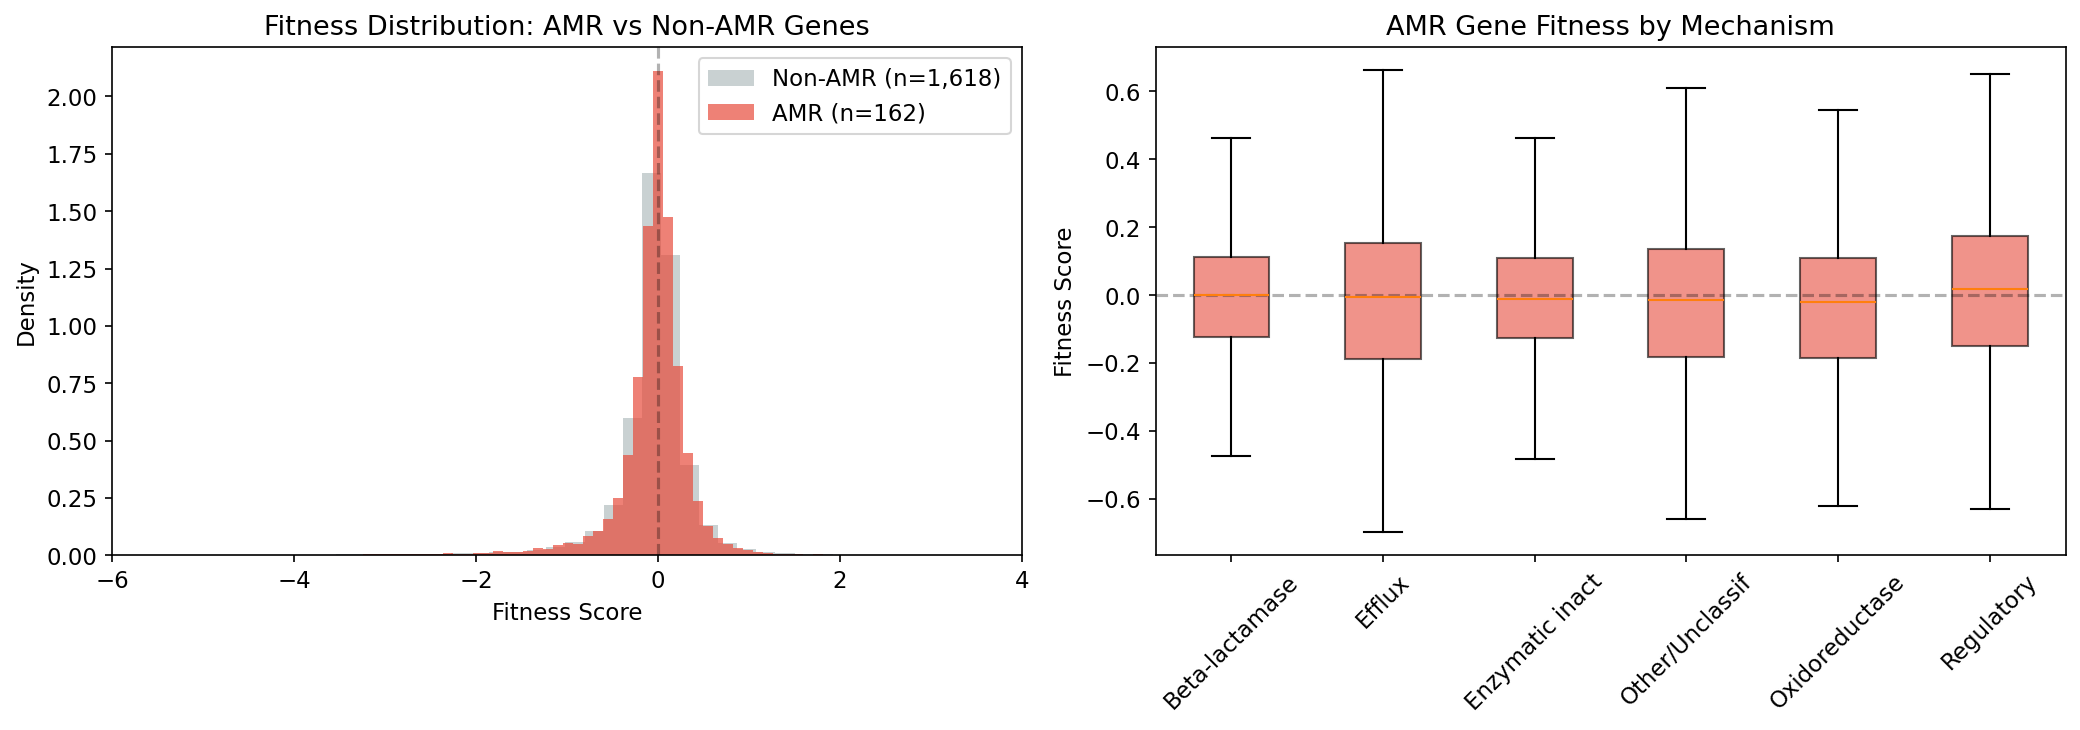

In [4]:
# Compare AMR vs non-AMR fitness
print("=== AMR Gene Fitness Summary ===")
print(f"Mean fitness: {amr_fitness['fitness'].mean():.4f}")
print(f"Median fitness: {amr_fitness['fitness'].median():.4f}")
print(f"% with sick phenotype (fitness < -1): {(amr_fitness['fitness'] < -1).mean()*100:.1f}%")
print(f"% with strong sick (fitness < -2): {(amr_fitness['fitness'] < -2).mean()*100:.1f}%")

print(f"\n=== Baseline (non-AMR) Fitness Summary ===")
print(f"Mean fitness: {baseline_fitness['fitness'].mean():.4f}")
print(f"Median fitness: {baseline_fitness['fitness'].median():.4f}")
print(f"% with sick phenotype (fitness < -1): {(baseline_fitness['fitness'] < -1).mean()*100:.1f}%")

# Mann-Whitney test
u_stat, p_mw = stats.mannwhitneyu(amr_fitness['fitness'].dropna(), baseline_fitness['fitness'].dropna())
print(f"\nMann-Whitney (AMR vs non-AMR): U={u_stat:.0f}, p={p_mw:.2e}")

# Merge AMR gene info for per-mechanism analysis
amr_fitness_ann = amr_fitness.merge(fb_amr[['locusId', 'amr_gene', 'mechanism', 'conservation_class']].drop_duplicates('locusId'),
                                      on='locusId', how='left')

# Fitness by mechanism
print(f"\n=== Median Fitness by AMR Mechanism ===")
mech_fit = amr_fitness_ann.groupby('mechanism')['fitness'].agg(['median', 'mean', 'count']).round(4)
mech_fit = mech_fit.sort_values('median')
print(mech_fit.to_string())

# Fitness by conservation class
print(f"\n=== Median Fitness by Conservation Class ===")
cons_fit = amr_fitness_ann.groupby('conservation_class')['fitness'].agg(['median', 'mean', 'count']).round(4)
print(cons_fit.to_string())

# Save
amr_fitness_ann.to_csv(DATA_DIR / 'amr_fitness.csv', index=False)
print(f"\nSaved {len(amr_fitness_ann):,} fitness measurements to data/amr_fitness.csv")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: AMR vs baseline distribution
axes[0].hist(baseline_fitness['fitness'].dropna(), bins=100, alpha=0.5, color='#95a5a6',
             label=f'Non-AMR (n={baseline_fitness["locusId"].nunique():,})', density=True)
axes[0].hist(amr_fitness['fitness'].dropna(), bins=100, alpha=0.7, color='#e74c3c',
             label=f'AMR (n={amr_fitness["locusId"].nunique():,})', density=True)
axes[0].axvline(0, color='black', linestyle='--', alpha=0.3)
axes[0].set_xlabel('Fitness Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Fitness Distribution: AMR vs Non-AMR Genes')
axes[0].legend()
axes[0].set_xlim(-6, 4)

# Panel 2: Fitness by mechanism
mechs = amr_fitness_ann.groupby('mechanism').filter(lambda x: len(x) >= 50)['mechanism'].unique()
bp_data = [amr_fitness_ann[amr_fitness_ann['mechanism'] == m]['fitness'].dropna().values for m in sorted(mechs)]
bp = axes[1].boxplot(bp_data, labels=[m[:15] for m in sorted(mechs)], vert=True, patch_artist=True,
                      showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor('#e74c3c')
    patch.set_alpha(0.6)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[1].set_ylabel('Fitness Score')
axes[1].set_title('AMR Gene Fitness by Mechanism')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIG_DIR / 'amr_fitness_distribution.png')
plt.show()